MLE Estimated Parameters
------------------------
Normal (mean, std):
(np.float64(8.396435157705497), np.float64(4.717524256560593))

Weibull (shape, loc, scale):
(np.float64(1.6143329159421271), np.float64(1.4384669347078276), np.float64(7.810281328404967))

Lognormal (shape, loc, scale):
(np.float64(0.5277084108153951), 0.4735423318951917, np.float64(6.876494120415978))


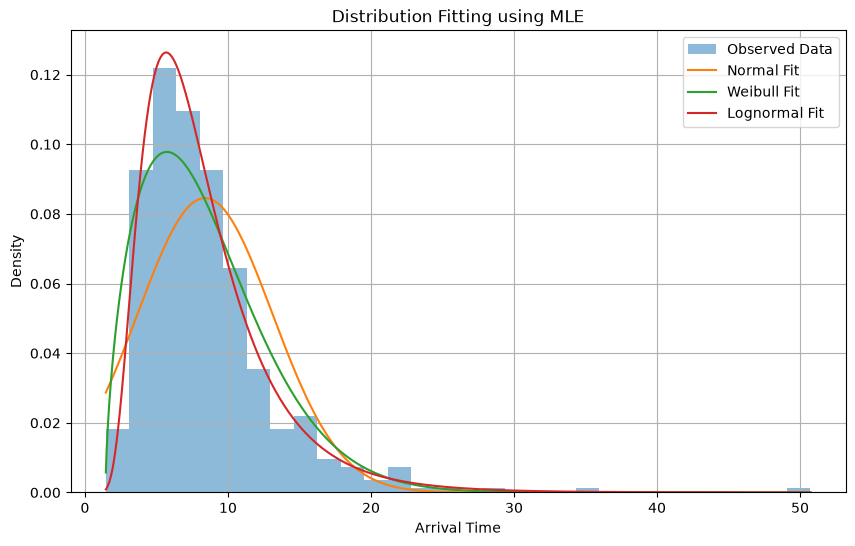

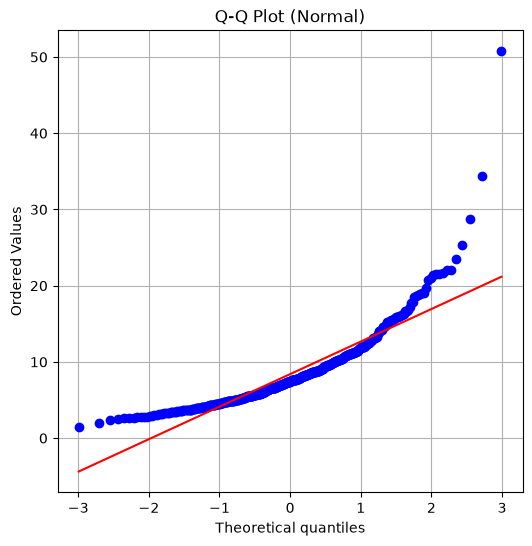

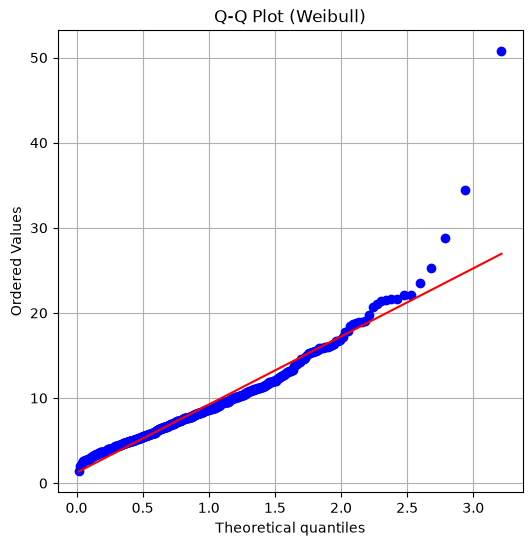

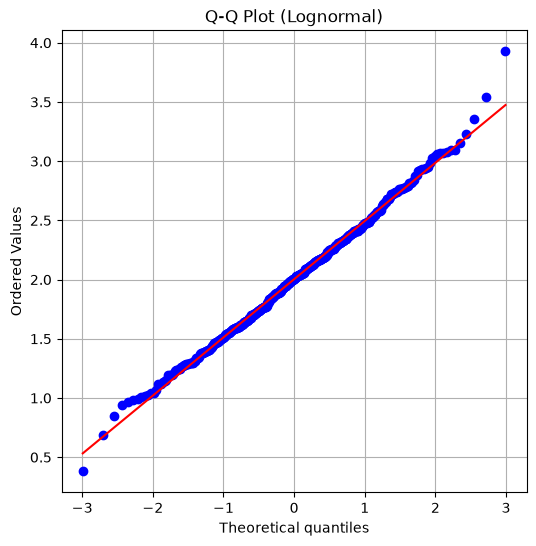

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------------
# Example Raw Dataset
# ----------------------------------
np.random.seed(42)

# Simulated customer arrival times
data = np.random.lognormal(mean=2.0, sigma=0.5, size=500)

# ----------------------------------
# Fit Distributions using MLE
# ----------------------------------

# Normal Distribution
norm_params = stats.norm.fit(data)

# Weibull Distribution
weibull_params = stats.weibull_min.fit(data)

# Lognormal Distribution
lognorm_params = stats.lognorm.fit(data)

print("MLE Estimated Parameters")
print("------------------------")
print("Normal (mean, std):")
print(norm_params)

print("\nWeibull (shape, loc, scale):")
print(weibull_params)

print("\nLognormal (shape, loc, scale):")
print(lognorm_params)

# ----------------------------------
# Histogram + Fitted Curves
# ----------------------------------

x = np.linspace(min(data), max(data), 1000)

plt.figure(figsize=(10,6))

plt.hist(data,
         bins=30,
         density=True,
         alpha=0.5,
         label="Observed Data")

plt.plot(
    x,
    stats.norm.pdf(x, *norm_params),
    label="Normal Fit"
)

plt.plot(
    x,
    stats.weibull_min.pdf(x, *weibull_params),
    label="Weibull Fit"
)

plt.plot(
    x,
    stats.lognorm.pdf(x, *lognorm_params),
    label="Lognormal Fit"
)

plt.title("Distribution Fitting using MLE")
plt.xlabel("Arrival Time")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# Q-Q Plot : Normal
# ----------------------------------
plt.figure(figsize=(6,6))
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot (Normal)")
plt.grid(True)
plt.show()

# ----------------------------------
# Q-Q Plot : Weibull
# ----------------------------------
plt.figure(figsize=(6,6))
stats.probplot(
    data,
    dist=stats.weibull_min,
    sparams=weibull_params[:-2],
    plot=plt
)
plt.title("Q-Q Plot (Weibull)")
plt.grid(True)
plt.show()

# ----------------------------------
# Q-Q Plot : Lognormal
# ----------------------------------
plt.figure(figsize=(6,6))
stats.probplot(
    np.log(data),
    dist="norm",
    plot=plt
)
plt.title("Q-Q Plot (Lognormal)")
plt.grid(True)
plt.show()